In [1]:
# prompt: connect drive

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install bnltk

  Using cached bnltk-0.7.8-py3-none-any.whl.metadata (5.1 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.2/79.2 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 79.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled ker

In [2]:
import pandas as pd
import numpy as np
import re
import nltk


# For scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

# For deep learning
import tensorflow as tf
from tensorflow.keras import layers


In [3]:
nltk.download('punkt')
nltk.download('stopwords')
# If needed for lemmatization
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [4]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [6]:
df = pd.read_excel('/content/drive/MyDrive/Thesis/version30k.xlsx')
# df = pd.read_excel('/content/drive/MyDrive/Thesis/500.xlsx')
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30117 entries, 0 to 30116
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Abuse Text  30117 non-null  object
 1   Aspects     30117 non-null  object
 2   Outcome     30117 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 706.0+ KB
None
                                          Abuse Text  Aspects  Outcome
0  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...    Toxic        1
1  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...  Obscene        0
2  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...   Insult        1
3   এই মাদ্রাসার হোগুরকে ডিলডো মেরে শাস্তি দেয়া হোক।    Toxic        1
4   এই মাদ্রাসার হোগুরকে ডিলডো মেরে শাস্তি দেয়া হোক।  Obscene        0


In [7]:
df["combined_text"] = df["Abuse Text"].astype(str) + " " + df["Aspects"].astype(str)
print(df[["Abuse Text", "Aspects", "combined_text", "Outcome"]].head())

                                          Abuse Text  Aspects  \
0  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...    Toxic   
1  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...  Obscene   
2  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...   Insult   
3   এই মাদ্রাসার হোগুরকে ডিলডো মেরে শাস্তি দেয়া হোক।    Toxic   
4   এই মাদ্রাসার হোগুরকে ডিলডো মেরে শাস্তি দেয়া হোক।  Obscene   

                                       combined_text  Outcome  
0  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...        1  
1  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...        0  
2  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...        1  
3  এই মাদ্রাসার হোগুরকে ডিলডো মেরে শাস্তি দেয়া হো...        1  
4  এই মাদ্রাসার হোগুরকে ডিলডো মেরে শাস্তি দেয়া হো...        0  


In [8]:
from nltk.corpus import stopwords

# Example set of Bangla stopwords (expand as needed)
bangla_stopwords = {
    "আমি", "এটি", "এই", "সেই", "তুমি", "যে", "সে", "এঁই", "ওই",
    "এগুলি", "ওগুলি", "এগুলো", "ওগুলো"
    # etc.
}

def clean_text(text):
    # Lowercase (optional for Bangla if needed)
    text = text.lower()
    # Remove unwanted characters, digits, punctuation
    text = re.sub(r"[^ঀ-৿a-zA-Z]+", " ", text)
    text = text.strip()
    return text

def tokenize_and_remove_stopwords(text):
    tokens = nltk.word_tokenize(text)
    # For specialized Bangla tokenization, consider BN-NLTK or others
    filtered_tokens = [t for t in tokens if t not in bangla_stopwords]
    return filtered_tokens

def preprocess_bangla_text(text):
    # 1) Clean
    text = clean_text(text)
    # 2) Tokenize + remove stopwords
    tokens = tokenize_and_remove_stopwords(text)
    # 3) (Optional) Stemming or Lemmatization (requires appropriate library)
    # 4) Join tokens back for vectorization
    return " ".join(tokens)

df["cleaned_text"] = df["combined_text"].apply(preprocess_bangla_text)
print(df[["combined_text", "cleaned_text", "Outcome"]].head())

                                       combined_text  \
0  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...   
1  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...   
2  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...   
3  এই মাদ্রাসার হোগুরকে ডিলডো মেরে শাস্তি দেয়া হো...   
4  এই মাদ্রাসার হোগুরকে ডিলডো মেরে শাস্তি দেয়া হো...   

                                        cleaned_text  Outcome  
0  গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার যত্তসব...        1  
1  গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার যত্তসব...        0  
2  গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার যত্তসব...        1  
3  মাদ্রাসার হোগুরকে ডিলডো মেরে শাস্তি দেয়া হোক t...        1  
4  মাদ্রাসার হোগুরকে ডিলডো মেরে শাস্তি দেয়া হোক o...        0  


In [9]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["cleaned_text"])
y = df["Outcome"]  # The target column

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)

y_pred = lr_clf.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.8555776892430279
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.91      0.89      3800
           1       0.83      0.76      0.80      2224

    accuracy                           0.86      6024
   macro avg       0.85      0.84      0.84      6024
weighted avg       0.85      0.86      0.85      6024



In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'max_iter': [100, 200, 300]
}
grid = GridSearchCV(LogisticRegression(), param_grid, cv=3)
grid.fit(X_train, y_train)

best_lr = grid.best_estimator_
print("Best parameters for LogisticRegression:", grid.best_params_)

y_pred_best = best_lr.predict(X_test)
print("Tuned LogisticRegression Accuracy:", accuracy_score(y_test, y_pred_best))

Best parameters for LogisticRegression: {'C': 10, 'max_iter': 100}
Tuned LogisticRegression Accuracy: 0.8663678618857902


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
rf_clf = RandomForestClassifier(n_estimators=50, random_state=42)
nb_clf = MultinomialNB()

ensemble_clf = VotingClassifier(
    estimators=[
        ('lr', best_lr),
        ('rf', rf_clf),
        ('nb', nb_clf)
    ],
    voting='hard'
)
ensemble_clf.fit(X_train, y_train)
y_pred_ens = ensemble_clf.predict(X_test)
print("Ensemble Accuracy:", accuracy_score(y_test, y_pred_ens))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Ensemble Accuracy: 0.8701859229747676


# BERT

In [ ]:

import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Hugging Face Transformers
from transformers import BertTokenizer, BertForSequenceClassification, AdamW

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [ ]:
# Combine text input columns (Abuse Text + Aspects)
df["combined_text"] = df["Abuse Text"].astype(str) + " " + df["Aspects"].astype(str)

# Train-test split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=41)
train_texts = train_df["combined_text"].tolist()
y_train = train_df["Outcome"].tolist()

test_texts = test_df["combined_text"].tolist()
y_test = test_df["Outcome"].tolist()

print("Train size:", len(train_texts), "Test size:", len(test_texts))

Train size: 24093 Test size: 6024


In [ ]:
class BengaliDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
model_name = "bert-base-multilingual-cased"  # or "sagorsarker/bangla-bert-base"
max_length = 128
batch_size = 32

bert_tokenizer = BertTokenizer.from_pretrained(model_name)

train_dataset = BengaliDataset(train_texts, y_train, bert_tokenizer, max_length)
test_dataset = BengaliDataset(test_texts, y_test, bert_tokenizer, max_length)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

In [ ]:
bert_model = BertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2  # Binary classification
)
bert_model.to(device)

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

not this


In [ ]:
import torch
import matplotlib.pyplot as plt

optimizer = AdamW(bert_model.parameters(), lr=2e-5)
loss_fn = nn.CrossEntropyLoss()

epochs = 3  # set as needed
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    bert_model.train()
    total_loss = 0
    correct_preds = 0
    total_samples = 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = bert_model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        # Calculate training accuracy
        preds = torch.argmax(logits, dim=1)
        correct_preds += (preds == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = total_loss / len(train_loader)
    epoch_acc = correct_preds / total_samples
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{epochs}] | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch [1/3] | Loss: 0.1984 | Acc: 0.9245


KeyboardInterrupt: 

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")  # Modern style for plots

optimizer = AdamW(bert_model.parameters(), lr=2e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.9)  # Example scheduler
loss_fn = nn.CrossEntropyLoss()

epochs = 5 # set as needed
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
learning_rates = []

# Create a validation data loader
# Assuming you have a 'val_dataset' (create it similarly to train_dataset)
val_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # Assuming test_dataset as val_dataset for now


for epoch in range(epochs):
    bert_model.train()
    total_loss = 0
    correct_preds = 0
    total_samples = 0

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = bert_model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct_preds += (preds == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = total_loss / len(train_loader)
    epoch_acc = correct_preds / total_samples
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    learning_rates.append(optimizer.param_groups[0]['lr'])  # Store LR

    # Validation phase
    bert_model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = bert_model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            val_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_epoch_loss = val_loss / len(val_loader)
    val_epoch_acc = val_correct / val_total
    val_losses.append(val_epoch_loss)
    val_accuracies.append(val_epoch_acc)

    scheduler.step()  # Update learning rate

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

/usr/local/lib/python3.11/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch [1/5] | Train Loss: 0.2003 | Train Acc: 0.9235 | Val Loss: 0.1393 | Val Acc: 0.9464 | LR: 0.000018
Epoch [2/5] | Train Loss: 0.1170 | Train Acc: 0.9581 | Val Loss: 0.1161 | Val Acc: 0.9578 | LR: 0.000016
Epoch [3/5] | Train Loss: 0.0953 | Train Acc: 0.9664 | Val Loss: 0.1025 | Val Acc: 0.9645 | LR: 0.000015
Epoch [4/5] | Train Loss: 0.0859 | Train Acc: 0.9703 | Val Loss: 0.0944 | Val Acc: 0.9683 | LR: 0.000013
Epoch [5/5] | Train Loss: 0.0734 | Train Acc: 0.9747 | Val Loss: 0.0951 | Val Acc: 0.9660 | LR: 0.000012


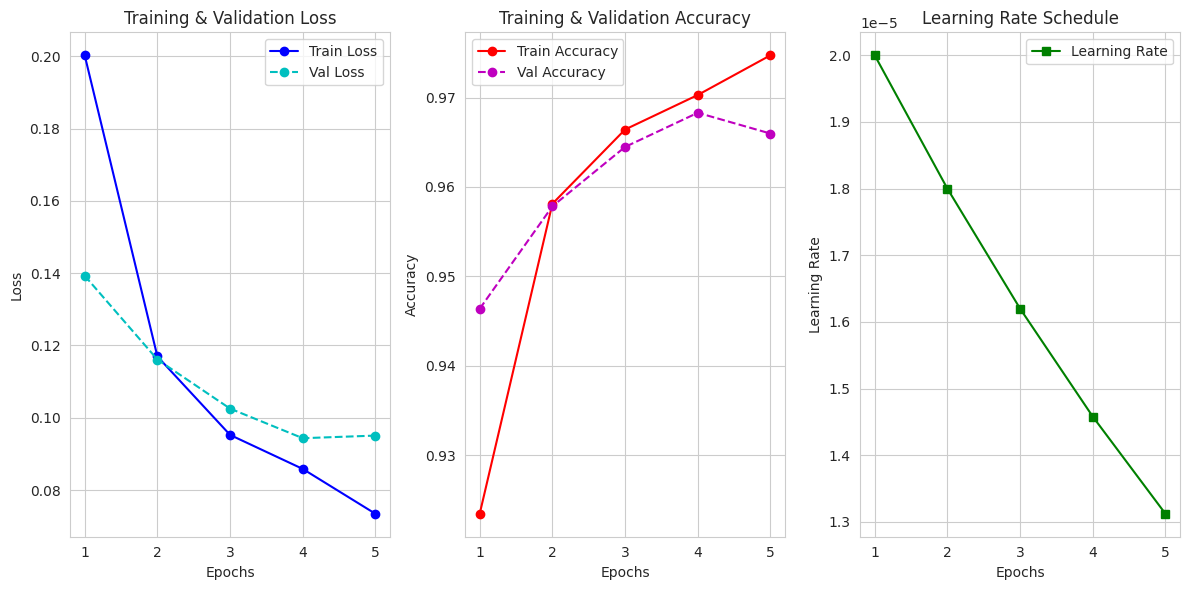

In [ ]:


# Plot Training & Validation Loss and Accuracy
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.plot(range(1, epochs + 1), train_losses, marker='o', linestyle='-', color='b', label='Train Loss')
plt.plot(range(1, epochs + 1), val_losses, marker='o', linestyle='--', color='c', label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(range(1, epochs + 1), train_accuracies, marker='o', linestyle='-', color='r', label='Train Accuracy')
plt.plot(range(1, epochs + 1), val_accuracies, marker='o', linestyle='--', color='m', label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(range(1, epochs + 1), learning_rates, marker='s', linestyle='-', color='g', label='Learning Rate')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.legend()

plt.tight_layout()
plt.savefig('train_val_loss_accuracy_lr.png')  # Save the figure
plt.show()


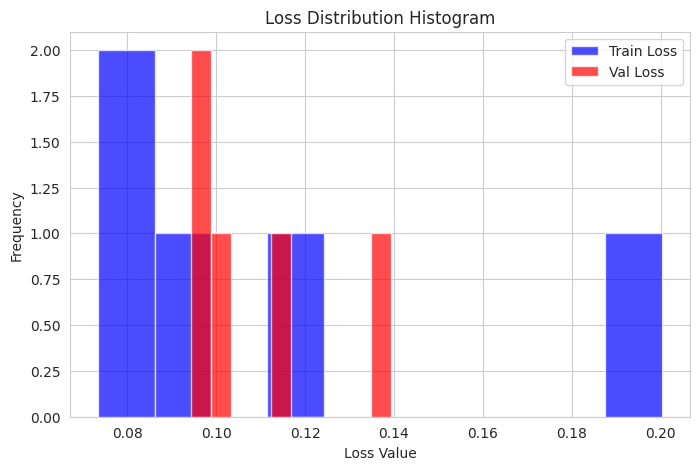

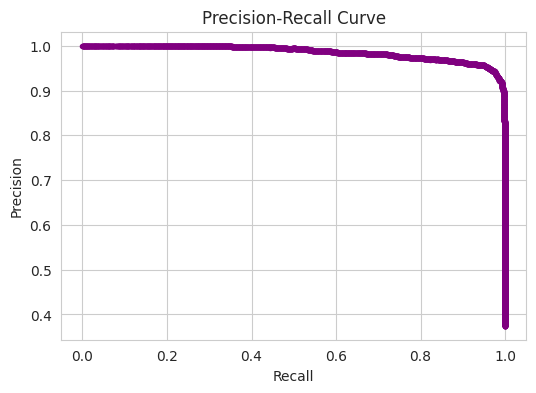

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import precision_recall_curve, roc_curve, auc

sns.set_style("whitegrid")  # Modern style for plots

# Loss Distribution Histogram
plt.figure(figsize=(8, 5))
plt.hist(train_losses, bins=10, color='blue', alpha=0.7, label='Train Loss')
plt.hist(val_losses, bins=10, color='red', alpha=0.7, label='Val Loss')
plt.xlabel("Loss Value")
plt.ylabel("Frequency")
plt.title("Loss Distribution Histogram")
plt.legend()
plt.savefig("loss_distribution_histogram.png")
plt.show()

# Precision-Recall Curve (for binary classification)
y_true = []
y_scores = []
bert_model.eval()
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = bert_model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)[:, 1]  # Assuming binary classification

        y_true.extend(labels.cpu().numpy())
        y_scores.extend(probabilities.cpu().numpy())

precision, recall, _ = precision_recall_curve(y_true, y_scores)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, marker='.', color='purple')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.savefig("precision_recall_curve.png")
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, confusion_matrix, classification_report

bert_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = bert_model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

# Compute classification metrics
test_accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')
mcc = matthews_corrcoef(all_labels, all_preds)

# Compute specificity (for binary classification)
conf_matrix = confusion_matrix(all_labels, all_preds)
if conf_matrix.shape == (2, 2):  # Ensure it's binary classification
    tn, fp, fn, tp = conf_matrix.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
else:
    specificity = 0.0  # Specificity is not defined for multi-class problems

# Compute ROC-AUC Score (only for binary classification)
roc_auc = roc_auc_score(all_labels, all_preds) if len(set(all_labels)) == 2 else 0.0

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"MCC: {mcc:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))


Test Accuracy: 0.9660
Precision: 0.9671
Recall: 0.9660
F1 Score: 0.9661
Specificity: 0.9570
ROC-AUC Score: 0.9690
MCC: 0.9290

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      3766
           1       0.93      0.98      0.96      2258

    accuracy                           0.97      6024
   macro avg       0.96      0.97      0.96      6024
weighted avg       0.97      0.97      0.97      6024



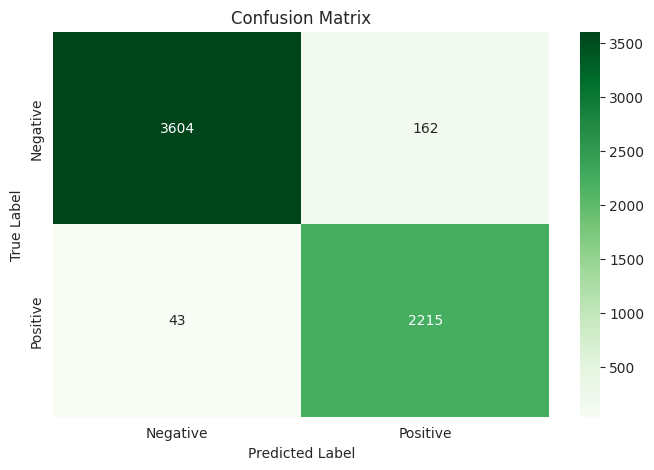

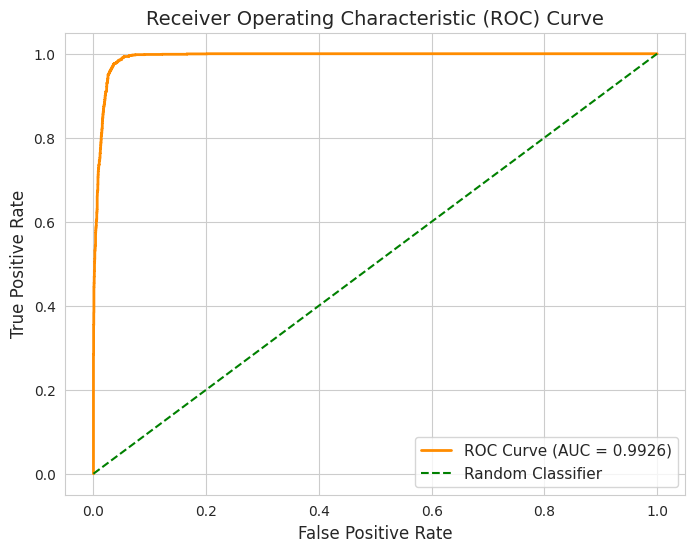

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import precision_recall_curve, roc_curve, auc, confusion_matrix
import seaborn as sns

sns.set_style("whitegrid")  # Modern style for plots



# Confusion Matrix
cm = confusion_matrix(y_true, np.round(y_scores))
plt.figure(figsize=(8,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

# ROC Curve
sns.set_style("whitegrid")

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='green', linestyle='--', lw=1.5, label="Random Classifier")

# Labels and title
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("Receiver Operating Characteristic (ROC) Curve", fontsize=14)
plt.legend(fontsize=11)

# Save and show plot
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()


# RoBERTa Model

In [ ]:
from transformers import RobertaTokenizer
import torch
from torch.utils.data import Dataset

# Load the pre-trained RoBERTa tokenizer
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

# Define a custom Dataset class for text classification
class TextDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.texts = dataframe['combined_text'].tolist()
        self.labels = dataframe['Outcome'].tolist()  # Ensure labels are in the correct (e.g., numeric) format
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        # Tokenize the text
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        # Squeeze to remove extra batch dimension
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item['labels'] = torch.tensor(label, dtype=torch.long)
        return item

# Create the training and validation datasets
train_dataset = TextDataset(train_df, tokenizer)
val_dataset = TextDataset(test_df, tokenizer)

In [ ]:
from transformers import RobertaForSequenceClassification

# Determine the number of labels (e.g., for binary classification, num_labels=2)
num_labels = len(df["Outcome"].unique())

# Load the pre-trained RoBERTa model for sequence classification
model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=num_labels)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import RobertaConfig, RobertaForSequenceClassification

# Determine the number of unique labels (for example, binary classification => 2)
num_labels = len(df["Outcome"].unique())

# Create a custom configuration. These parameters match the typical RoBERTa base model.
# You can modify them to create a smaller model if computational resources are limited.
config = RobertaConfig(
    vocab_size=tokenizer.vocab_size,  # Ensure consistency with your tokenizer
    hidden_size=768,
    num_hidden_layers=12,
    num_attention_heads=12,
    intermediate_size=3072,
    max_position_embeddings=514,
    type_vocab_size=1,
    num_labels=num_labels,
)

# Initialize the RoBERTa model for sequence classification from scratch
model = RobertaForSequenceClassification(config)

In [ ]:
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, matthews_corrcoef
from scipy.special import softmax

# Define training arguments for the Trainer
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=128,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    evaluation_strategy="steps",
    eval_steps=300,
    report_to=[]  # Disables logging integrations (e.g., wandb, mlflow)
)

# Custom metric computation function
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Compute Accuracy, Precision, Recall and F1 Score
    acc = accuracy_score(labels, predictions)
    prec = precision_score(labels, predictions, zero_division=0)
    rec = recall_score(labels, predictions, zero_division=0)
    f1 = f1_score(labels, predictions, zero_division=0)

    # Compute Specificity: TN / (TN + FP)
    cm = confusion_matrix(labels, predictions)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    else:
        spec = 0.0

    # Compute ROC-AUC Score; extract probability for the positive class
    probs = softmax(logits, axis=1)[:, 1]
    roc_auc = roc_auc_score(labels, probs)

    # Compute Matthews Correlation Coefficient
    mcc = matthews_corrcoef(labels, predictions)

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "specificity": spec,
        "roc_auc": roc_auc,
        "mcc": mcc
    }

# Instantiate the Trainer with your pre-loaded RoBERTa model
trainer = Trainer(
    model=model,  # your RoBERTa model, e.g., loaded via RobertaForSequenceClassification.from_pretrained(...)
    args=training_args,
    train_dataset=train_dataset,  # defined elsewhere in your code
    eval_dataset=val_dataset,       # defined elsewhere in your code
    compute_metrics=compute_metrics
)

# Train the model
trainer.train()

# Evaluate the model on the validation set
eval_results = trainer.evaluate()

# Print the evaluation metrics formatted to 4 decimal places
print(f"Accuracy: {eval_results['eval_accuracy']:.4f}")
print(f"Precision: {eval_results['eval_precision']:.4f}")
print(f"Recall: {eval_results['eval_recall']:.4f}")
print(f"F1 Score: {eval_results['eval_f1']:.4f}")
print(f"Specificity: {eval_results['eval_specificity']:.4f}")
print(f"ROC-AUC Score: {eval_results['eval_roc_auc']:.4f}")
print(f"MCC: {eval_results['eval_mcc']:.4f}")

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Specificity,Roc Auc,Mcc
300,0.217800,0.302268,0.886288,0.830046,0.875996,0.852402,0.892459,0.951228,0.760761
600,0.262900,0.312159,0.878818,0.858685,0.810009,0.833637,0.920074,0.944908,0.739242
900,0.287100,0.317800,0.866700,0.897324,0.727635,0.803619,0.950080,0.946509,0.713251
1200,0.297200,0.329331,0.884794,0.865079,0.820638,0.842273,0.923261,0.943771,0.752278
1500,0.302000,0.353117,0.878154,0.870262,0.793180,0.829935,0.929102,0.948366,0.737242
1800,0.375900,0.314914,0.884296,0.805002,0.912312,0.855304,0.867499,0.947871,0.763668
2100,0.224100,0.269861,0.898074,0.838272,0.902126,0.869027,0.895645,0.954026,0.787206


Accuracy: 0.9014
Precision: 0.8490
Recall: 0.8964
F1 Score: 0.8720
Specificity: 0.9044
ROC-AUC Score: 0.9544
MCC: 0.7927


# LSTM

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Assume your DataFrame is already loaded as 'df'
df["combined_text"] = df["Abuse Text"].astype(str) + " " + df["Aspects"].astype(str)
print(df[["Abuse Text", "Aspects", "combined_text", "Outcome"]].head())

# Split the DataFrame into training and validation sets (80% training, 20% validation)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

                                          Abuse Text  Aspects  \
0  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...    Toxic   
1  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...  Obscene   
2  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...   Insult   
3   এই মাদ্রাসার হোগুরকে ডিলডো মেরে শাস্তি দেয়া হোক।    Toxic   
4   এই মাদ্রাসার হোগুরকে ডিলডো মেরে শাস্তি দেয়া হোক।  Obscene   

                                       combined_text  Outcome  
0  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...        1  
1  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...        0  
2  এই গুলার জায়গামতো চুঁচড়া লাগিয়ে দেয়া দরকার! যত...        1  
3  এই মাদ্রাসার হোগুরকে ডিলডো মেরে শাস্তি দেয়া হো...        1  
4  এই মাদ্রাসার হোগুরকে ডিলডো মেরে শাস্তি দেয়া হো...        0  


In [12]:
from collections import Counter
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

def build_vocab(texts, min_freq=1):
    counter = Counter()
    for text in texts:
        words = text.split()
        counter.update(words)
    # Reserve 0 for PAD and 1 for UNK
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, count in counter.items():
        if count >= min_freq:
            vocab[word] = len(vocab)
    return vocab

class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = texts
        self.labels = labels  # Assuming labels are already numeric
        self.vocab = vocab

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        words = text.split()
        # Convert each word to its index; if not found, use the index for <UNK>
        indices = [self.vocab.get(word, self.vocab["<UNK>"]) for word in words]
        label = self.labels[idx]
        return torch.tensor(indices, dtype=torch.long), torch.tensor(label, dtype=torch.long)

# Prepare training and validation texts and labels
train_texts = train_df["combined_text"].tolist()
train_labels = train_df["Outcome"].tolist()
val_texts = val_df["combined_text"].tolist()
val_labels = val_df["Outcome"].tolist()

# Build vocabulary using the training texts
vocab = build_vocab(train_texts, min_freq=1)
print("Vocabulary size:", len(vocab))

# Create Dataset instances
train_dataset = TextDataset(train_texts, train_labels, vocab)
val_dataset = TextDataset(val_texts, val_labels, vocab)

# Define a collate function to pad sequences in each batch
def collate_fn(batch):
    texts, labels = zip(*batch)
    # Pad sequences with the PAD token (index 0)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=0)
    labels = torch.stack(labels)
    return texts_padded, labels

# Create DataLoaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

Vocabulary size: 22015


In [13]:
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=1, drop_prob=0.5):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=drop_prob if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(drop_prob)

    def forward(self, x):
        # x: (batch_size, seq_length)
        embeds = self.embedding(x)  # (batch_size, seq_len, embed_dim)
        lstm_out, (hidden, cell) = self.lstm(embeds)
        # Use the hidden state of the last LSTM layer
        out = hidden[-1]  # (batch_size, hidden_dim)
        out = self.dropout(out)
        out = self.fc(out)  # (batch_size, num_classes)
        return out

# Define hyperparameters
vocab_size = len(vocab)
embed_dim = 128
hidden_dim = 128
num_classes = len(set(train_labels))  # e.g., 2 for binary classification

# Initialize the model
model = LSTMClassifier(vocab_size, embed_dim, hidden_dim, num_classes)

In [14]:
import torch.optim as optim

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5  # Adjust the number of epochs as needed

# Training loop
model.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    for texts, labels in train_loader:
        optimizer.zero_grad()              # Zero the gradients
        outputs = model(texts)             # Forward pass
        loss = criterion(outputs, labels)  # Compute the loss
        loss.backward()                    # Backward pass
        optimizer.step()                   # Update the parameters

        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 1/5, Loss: 0.3323
Epoch 2/5, Loss: 0.1516
Epoch 3/5, Loss: 0.1065
Epoch 4/5, Loss: 0.0802
Epoch 5/5, Loss: 0.0585


In [15]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for texts, labels in val_loader:
        outputs = model(texts)
        # Get the predicted class (highest logit value)
        _, predicted = torch.max(outputs, dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Validation Accuracy: {accuracy:.4f}%")

Validation Accuracy: 95.8001%


In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score, confusion_matrix, accuracy_score # import confusion_matrix

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for texts, labels in val_loader:
        outputs = model(texts)
        _, predicted = torch.max(outputs, dim=1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute classification metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
mcc = matthews_corrcoef(all_labels, all_preds)

# Compute specificity (for binary classification)
conf_matrix = confusion_matrix(all_labels, all_preds)
if conf_matrix.shape == (2, 2):  # Ensure it's binary classification
    tn, fp, fn, tp = conf_matrix.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
else:
    specificity = 0.0  # Specificity is not defined for multi-class problems

# Compute ROC-AUC Score (only for binary classification)
roc_auc = roc_auc_score(all_labels, all_preds) if len(set(all_labels)) == 2 else 0.0


print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"MCC: {mcc:.4f}")

Accuracy: 0.9580
Precision: 0.9583
Recall: 0.9580
F1 Score: 0.9581
Specificity: 0.9608
ROC-AUC Score: 0.9570
MCC: 0.9103


ML MOdels

In [19]:
# prompt: train xgb with hyper tuning

import xgboost as xgb
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize the XGBoost classifier
xgb_model = xgb.XGBClassifier(objective='binary:logistic', random_state=42, eval_metric='logloss')

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit the grid search to your training data
grid_search.fit(X_train, y_train) # Replace X_train, y_train with actual data

# Get the best hyperparameters and the best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best Hyperparameters:", best_params)

# Evaluate the best model (example using accuracy)
accuracy = best_model.score(X_test, y_test)  # Replace X_test, y_test with actual data
print(f"Accuracy of the best model: {accuracy}")


Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.3, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}
Accuracy of the best model: 0.8849601593625498


In [21]:


from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score


# Compute classification metrics
accuracy = best_model.score(X_test, y_test)
precision = precision_score(y_test, best_model.predict(X_test), average='weighted', zero_division=0)
recall = recall_score(y_test, best_model.predict(X_test), average='weighted', zero_division=0)
f1 = f1_score(y_test, best_model.predict(X_test), average='weighted', zero_division=0)
mcc = matthews_corrcoef(y_test, best_model.predict(X_test))


# Compute specificity (for binary classification)
conf_matrix = confusion_matrix(y_test, best_model.predict(X_test))
if conf_matrix.shape == (2, 2):  # Ensure it's binary classification
    tn, fp, fn, tp = conf_matrix.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
else:
    specificity = 0.0  # Specificity is not defined for multi-class problems

# Compute ROC-AUC Score (only for binary classification)
y_scores = best_model.predict_proba(X_test)[:, 1] # Assuming binary classification
roc_auc = roc_auc_score(y_test, y_scores) if len(set(y_test)) == 2 else 0.0


print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"MCC: {mcc:.4f}")


Accuracy: 0.8850
Precision: 0.8859
Recall: 0.8850
F1 Score: 0.8853
Specificity: 0.9000
ROC-AUC Score: 0.9518
MCC: 0.7548


In [23]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, roc_auc_score, confusion_matrix

# Define hyperparameter grids
gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize models
gb_model = GradientBoostingClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)

# Grid search for GB
gb_grid_search = GridSearchCV(estimator=gb_model, param_grid=gb_param_grid, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)
gb_grid_search.fit(X_train, y_train)
gb_best_model = gb_grid_search.best_estimator_

# Grid search for RF
rf_grid_search = GridSearchCV(estimator=rf_model, param_grid=rf_param_grid, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)
rf_grid_search.fit(X_train, y_train)
rf_best_model = rf_grid_search.best_estimator_

# Evaluate models on test data
def evaluate_model(model, X_test, y_test):
    accuracy = model.score(X_test, y_test)
    precision = precision_score(y_test, model.predict(X_test), average='weighted', zero_division=0)
    recall = recall_score(y_test, model.predict(X_test), average='weighted', zero_division=0)
    f1 = f1_score(y_test, model.predict(X_test), average='weighted', zero_division=0)
    mcc = matthews_corrcoef(y_test, model.predict(X_test))

    # Compute specificity (for binary classification)
    conf_matrix = confusion_matrix(y_test, model.predict(X_test))
    if conf_matrix.shape == (2, 2):
        tn, fp, fn, tp = conf_matrix.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    else:
        specificity = 0.0

    # Compute ROC-AUC Score (only for binary classification)
    y_scores = model.predict_proba(X_test)[:, 1] if len(set(y_test)) == 2 else [0] * len(y_test)
    roc_auc = roc_auc_score(y_test, y_scores) if len(set(y_test)) == 2 else 0.0

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"ROC-AUC Score: {roc_auc:.4f}")
    print(f"MCC: {mcc:.4f}")

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'specificity': specificity,
        'roc_auc': roc_auc,
        'mcc': mcc
    }

print("Gradient Boosting Performance:")
gb_metrics = evaluate_model(gb_best_model, X_test, y_test)
print("\nRandom Forest Performance:")
rf_metrics = evaluate_model(rf_best_model, X_test, y_test)


Fitting 3 folds for each of 54 candidates, totalling 162 fits
Fitting 3 folds for each of 81 candidates, totalling 243 fits
Gradient Boosting Performance:
Accuracy: 0.9047
Precision: 0.9051
Recall: 0.9047
F1 Score: 0.9049
Specificity: 0.9192
ROC-AUC Score: 0.9625
MCC: 0.7963

Random Forest Performance:
Accuracy: 0.8861
Precision: 0.8867
Recall: 0.8861
F1 Score: 0.8864
Specificity: 0.9034
ROC-AUC Score: 0.9536
MCC: 0.7567


# RNN Classifier

# RNN + LSTM Hybrid Classifier

# CNN + LSTM Classifier

# BERT + CNN Model

# BERT + RNN

# CNN